# Predictions and experiments

This notebook asks whether each predicted structure is as close to the experimental structures of its
protein as those structures are to each other. The protein is the unit of analysis, since the comparisons
of one protein share structures. For each metric it reports the fraction of proteins whose prediction lies
within the experimental variability, with 95 % bootstrap intervals, and examines how that fraction
depends on the definition of the experimental variability, on coverage, on the assembly context of the
cryo-EM chain, on training overlap and on model confidence. It also compares AlphaFold2 with OpenFold3
and lists the proteins whose predictions lie furthest outside. The analysis is descriptive; no hypothesis
tests are performed.

**Input:** `results/` from notebooks 02 and 03.  
**Output:** `results/protein_table.csv`, `results/robustness.csv`, `results/method_pair_table.csv`,
`results/measurement_summary.json` and the figures in `results/figures/`.

In [1]:
import json
import os
import sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, ".")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.analysis import (
    AF2_TRAINING_CUTOFF,
    METRICS,
    OF3_TRAINING_CUTOFF,
    experimental_structures,
    format_summary,
    protein_table,
    summarise_proteins,
    training_overlap,
)
from src.baselines import (
    BASELINE_CONDITIONS,
    LEVEL_ORDER,
    ROBUSTNESS_CONDITIONS,
    baseline_levels,
    closest_experimental_method,
    context_table,
    method_pair_table,
    per_protein_pair_medians,
    protein_strata,
    robustness_table,
    robustness_wide,
    summarise_copies,
)
from src.figures import COLOR, LABEL, apply_style, log_floor, positive, save

apply_style()
with open("results/comparisons.json") as f:
    records = [r for r in json.load(f) if r.get("status") == "ok"]
copy_records = []
if os.path.exists("results/entry_copies.json"):  # written by notebook 03
    with open("results/entry_copies.json") as f:
        copy_records = json.load(f)

structures = experimental_structures(records)
table = protein_table(records)
summary = summarise_proteins(table)
strata = protein_strata(records, structures)
structures.to_csv("results/experimental_structures.csv", index=False)
table.to_csv("results/protein_table.csv", index=False)
summary.to_csv("results/protein_summary.csv", index=False)
findings = {}  # numbers for the reading at the end (results/measurement_summary.json)
print(
    f"{len(records)} comparison records | {len(table)} proteins | "
    f"{int(table['flagged'].sum())} with a flagged experimental structure | "
    f"entry copies from notebook 03: {len(copy_records)}"
)

3477 comparison records | 151 proteins | 16 with a flagged experimental structure | entry copies from notebook 03: 229


---
## 1. Flagged experimental structures

A structure is flagged when it is not a plain copy of the UniProt protein:

- **identity < 0.90** to the UniProt sequence: an engineered variant;
- **≥ 10 residues not matching the UniProt sequence**: expression tags, a fused protein;
- **title mentions amyloid, fibril, filament or cage**: a different assembly state.

Flagged proteins stay in the data; the headline is also given without them (section 4).

In [2]:
flagged = structures[structures["flagged"]]
print(
    f"{len(flagged)} of {len(structures)} experimental structures flagged, in {int(table['flagged'].sum())} of {len(table)} proteins"
)
print(flagged[["flag_identity", "flag_extra", "flag_state"]].sum().to_string())
display(
    flagged[["protein_name", "method", "pdb_id", "identity", "extra_residues", "title"]]
    .sort_values(["protein_name", "method"])
    .round(3)
)

17 of 392 experimental structures flagged, in 16 of 151 proteins
flag_identity     2
flag_extra        7
flag_state       10


,protein_name,method,pdb_id,identity,extra_residues,title
379,Apoptosis-associated speck-like protein contai...,Cryo-EM,9WZ7,1.000,0,Full-length ASCb filament
231,Aquaporin Z,Cryo-EM,8UY6,0.991,15,Aquaporin Z with ALFA tag and bound to nanobody
191,Aquaporin-1,NMR,6POJ,1.000,23,STRUCTURAL REFINEMENT OF AQUAPORIN 1 VIA SSNMR
185,Cofilin-1,Cryo-EM,9QFJ,1.000,0,Cryo-EM structure of the cofilactin filament c...
180,Cofilin-2 (P21566),Cryo-EM,5YU8,1.000,0,Cofilin decorated actin filament
384,Cofilin-2 (Q9Y281),Cryo-EM,9Y9P,1.000,0,Cofilactin filament
383,Cofilin-2 (Q9Y281),NMR,7M0G,1.000,0,Magic Angle Spinning NMR Structure of Human Co...
122,DNA damage-inducible protein I,Cryo-EM,7YWA,1.000,0,Structure of DinI in complex with RecA filament
208,Eukaryotic translation initiation factor 1,NMR,2IF1,1.000,13,"HUMAN TRANSLATION INITIATION FACTOR EIF1, NMR,..."
92,Lactococcin-A immunity protein,NMR,5LFI,1.000,19,lactococcin A immunity protein


---
## 2. The predictions on the ruler

**Left to right per metric:** the reference levels of notebook 03 (grey, tightest to loosest) and the
two predictions. **Below:** one point per protein — the prediction's median distance to the
experimental structures against the experimental variability (the median distance between the
experimental structures). Below the diagonal the prediction is closer to the experiments than they
are to each other; open markers are proteins with a flagged structure.

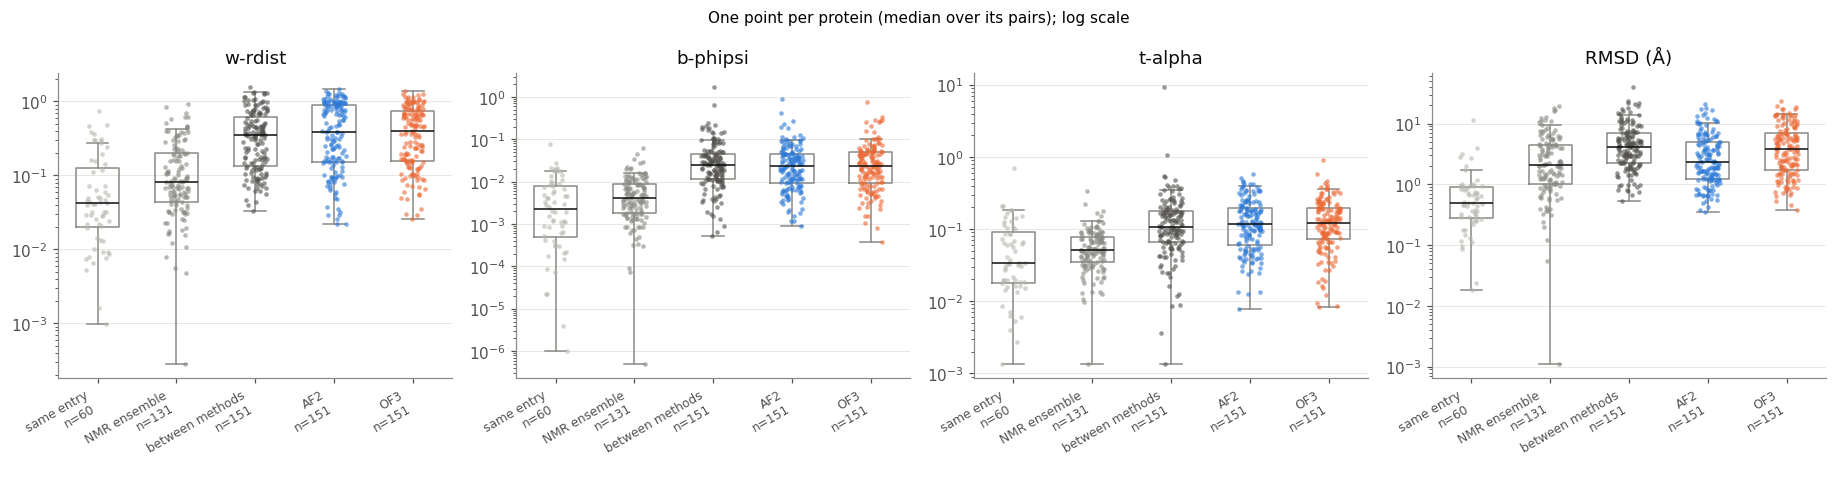

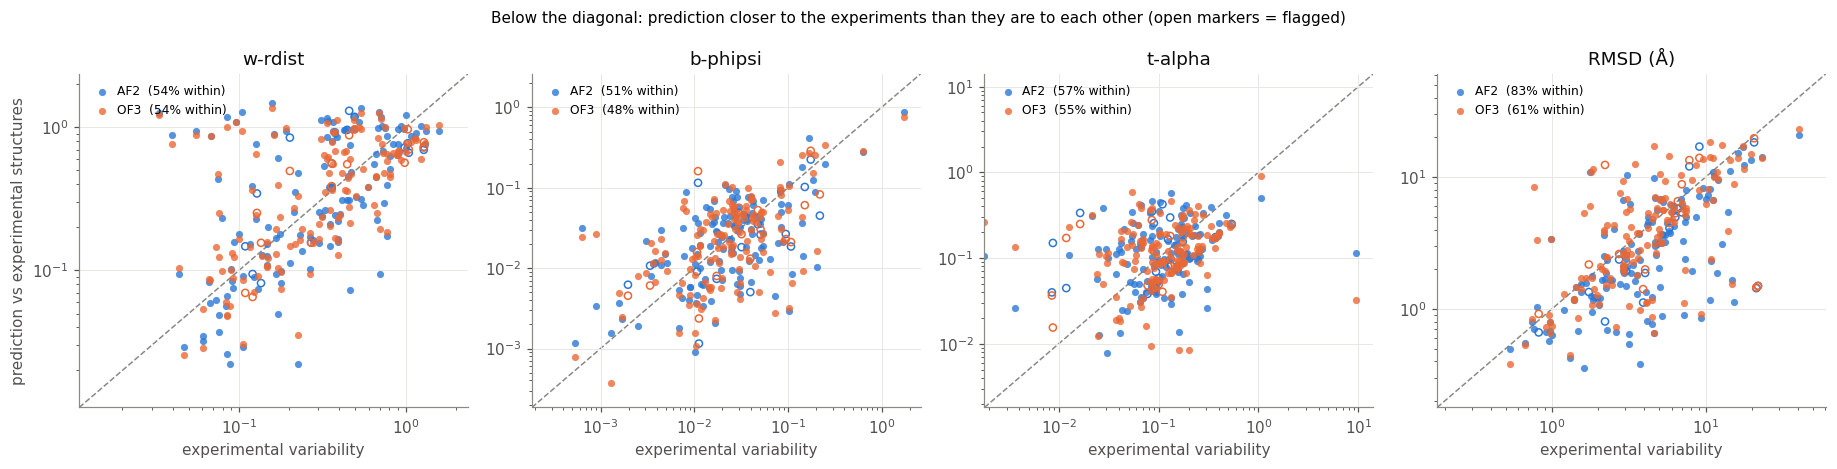

In [3]:
copy_summary = summarise_copies(copy_records)
fig, axes = plt.subplots(1, len(METRICS), figsize=(4.2 * len(METRICS), 4.4))
rng = np.random.default_rng(0)
for ax, m in zip(axes, METRICS):
    long = baseline_levels(table, copy_summary, m)
    present = [lvl for lvl in LEVEL_ORDER if lvl in set(long["level"])]
    data = [
        long.loc[long["level"] == lvl, "value"].to_numpy(dtype=float) for lvl in present
    ]
    floor_value = log_floor(*data)
    data = [positive(d, floor_value) for d in data]
    ax.boxplot(
        data,
        widths=0.55,
        showfliers=False,
        medianprops={"color": COLOR["text"]},
        boxprops={"color": COLOR["rule"]},
        whiskerprops={"color": COLOR["rule"]},
        capprops={"color": COLOR["rule"]},
    )
    for k, (lvl, d) in enumerate(zip(present, data), start=1):
        ax.scatter(
            k + rng.uniform(-0.15, 0.15, len(d)),
            d,
            s=9,
            color=COLOR[lvl],
            alpha=0.6,
            linewidths=0,
            zorder=2,
        )
    ax.set_yscale("log")
    ax.set_xticks(
        range(1, len(present) + 1),
        [f"{lvl}\nn={len(d)}" for lvl, d in zip(present, data)],
        fontsize=8,
        rotation=30,
        ha="right",
    )
    ax.set_title(LABEL[m])
    ax.grid(axis="x", visible=False)
fig.suptitle("One point per protein (median over its pairs); log scale", fontsize=10)
fig.tight_layout()
save(fig, "predictions_on_the_ruler")

fig, axes = plt.subplots(1, len(METRICS), figsize=(4.2 * len(METRICS), 4.3))
for ax, m in zip(axes, METRICS):
    values = table[[f"{m}__exp", f"{m}__af2", f"{m}__of3"]].to_numpy(dtype=float)
    floor_value = log_floor(values[np.isfinite(values)])
    lo, hi = floor_value, 1.5 * np.nanmax(values)
    ax.plot(
        [lo, hi], [lo, hi], color=COLOR["rule"], linewidth=1, linestyle="--", zorder=1
    )
    for pred in ("AF2", "OF3"):
        sub = table[[f"{m}__exp", f"{m}__{pred.lower()}", "flagged"]].dropna()
        x = positive(sub[f"{m}__exp"].to_numpy(), floor_value)
        y = positive(sub[f"{m}__{pred.lower()}"].to_numpy(), floor_value)
        clean = ~sub["flagged"].to_numpy(dtype=bool)
        within = (sub[f"{m}__{pred.lower()}"] <= sub[f"{m}__exp"]).mean()
        ax.scatter(
            x[clean],
            y[clean],
            s=22,
            color=COLOR[pred],
            alpha=0.8,
            linewidths=0,
            label=f"{pred}  ({within:.0%} within)",
            zorder=2,
        )
        ax.scatter(
            x[~clean],
            y[~clean],
            s=22,
            facecolors="none",
            edgecolors=COLOR[pred],
            linewidths=1,
            zorder=2,
        )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_title(LABEL[m])
    ax.set_xlabel("experimental variability")
    ax.legend(loc="upper left", fontsize=8, handletextpad=0.2)
axes[0].set_ylabel("prediction vs experimental structures")
fig.suptitle(
    "Below the diagonal: prediction closer to the experiments than they are to each other (open markers = flagged)",
    fontsize=10,
)
fig.tight_layout()
save(fig, "prediction_vs_experimental_variability")

---
## 3. The headline and its uncertainty

Section 2 compressed into one number per metric and prediction:

- **within experimental variability** — fraction of proteins whose prediction is no farther from the
  experimental structures than they are from each other (median distances);
- **median (prediction − experimental)** — in the metric's own units; negative = closer;
- **d_z** — paired effect size, mean / standard deviation of (prediction − experimental);
- **inside NMR ensemble** — fraction of proteins whose prediction is no farther from the
  representative NMR model than the farthest model of the same ensemble (a reference inside one
  experiment; only proteins whose NMR entry has more than one model).

Brackets: 95 % bootstrap intervals over proteins. "Within experimental variability" is a necessary,
not a sufficient, condition for saying that a prediction could replace an experiment.

In [4]:
display(format_summary(summary, "all"))
for m in METRICS:
    for pred in ("AF2", "OF3"):
        row = summary[
            (summary["subset"] == "all")
            & (summary["metric"] == m)
            & (summary["prediction"] == pred)
        ].iloc[0]
        findings[f"within_{m}_{pred}"] = [
            float(row["within_exp"]),
            float(row["within_exp_lo"]),
            float(row["within_exp_hi"]),
        ]
        findings[f"inside_nmr_{m}_{pred}"] = float(row["inside_nmr"])

,metric,prediction,n,within experimental variability,median (prediction - experimental),d_z,inside NMR ensemble,n (NMR ensemble)
0,w_rdist_norm,AF2,151,"0.54 [0.46, 0.62]","-0.0153 [-0.0387, 0.016]","0.25 [0.10, 0.39]","0.24 [0.18, 0.32]",131
1,w_rdist_norm,OF3,151,"0.54 [0.46, 0.62]","-0.0211 [-0.043, 0.0199]","0.15 [-0.00, 0.30]","0.24 [0.18, 0.32]",131
2,b_phipsi,AF2,151,"0.51 [0.43, 0.59]","-0.000469 [-0.00482, 0.00408]","-0.13 [-0.24, 0.02]","0.15 [0.09, 0.21]",131
3,b_phipsi,OF3,151,"0.48 [0.40, 0.56]","0.000793 [-0.00286, 0.00412]","-0.09 [-0.19, 0.10]","0.15 [0.09, 0.21]",131
4,t_alpha,AF2,151,"0.57 [0.49, 0.65]","-0.0175 [-0.0341, 0.00623]","-0.07 [-0.15, 0.17]","0.60 [0.51, 0.68]",131
5,t_alpha,OF3,151,"0.55 [0.47, 0.63]","-0.0151 [-0.029, 0.0169]","-0.07 [-0.15, 0.18]","0.57 [0.49, 0.66]",131
6,rmsd,AF2,151,"0.83 [0.77, 0.89]","-1.07 [-1.41, -0.791]","-0.46 [-0.59, -0.34]","0.33 [0.24, 0.41]",131
7,rmsd,OF3,151,"0.61 [0.53, 0.69]","-0.305 [-0.736, -0.118]","-0.08 [-0.23, 0.07]","0.26 [0.18, 0.34]",131


---
## 4. How robust is the headline?

The same fraction, recomputed under every condition that could change it. Each row answers one
question:

| Rows | Question |
|---|---|
| unflagged experimental structures | do engineered variants, tags and fibrils drive it? |
| 3 experimental pairs / 1 experimental pair | does it depend on how the experimental variability is estimated (three pairs, or one NMR–cryo-EM pair)? |
| length gap ≤ 10 % / ≤ 5 % in every pair | how much of it is coverage (notebook 03, 2a)? |
| cryo-EM entry with 1–4 / 20+ chains | does context (free protein vs subunit of an assembly) matter? |
| no structure public before the model's training cutoff | is it recall of training data? (very few proteins: wide intervals) |
| model confidence pLDDT ≥ 70 | is it driven by the model's own low-confidence predictions? |
| strict rule; baseline = X-ray–cryo-EM, NMR–cryo-EM, tightest pair | how much does the definition of "experimental variability" decide? |

Dotted lines in the figure: the fraction over all proteins. A statement about the predictions has to
hold across these rows; where it does not, the row says why.

metric                                                                            rmsd  \
prediction                                                                         AF2   
block    condition                                                                       
proteins all proteins                                        0.83 [0.77, 0.89] (n=151)   
         unflagged experimental structures                   0.82 [0.76, 0.89] (n=135)   
         X-ray, NMR and cryo-EM (3 experimental pairs)        0.84 [0.77, 0.91] (n=90)   
         NMR and cryo-EM only (1 experimental pair)           0.80 [0.70, 0.90] (n=61)   
         length gap ≤ 10 % in every pair                      0.91 [0.84, 0.97] (n=76)   
         length gap ≤ 5 % in every pair                       0.94 [0.87, 1.00] (n=52)   
         cryo-EM entry with 1–4 chains                        0.74 [0.58, 0.87] (n=31)   
         cryo-EM entry with 20+ chains                        0.90 [0.81, 0.98] (n=48)   
         no structure public before the model's training...   0.71 [0.43, 0.93] (n=14)   
         model confidence pLDDT ≥ 70                         0.86 [0.81, 0.91] (n=144)   
baseline strict rule (largest ≤ largest)                     0.45 [0.37, 0.53] (n=151)   
         baseline = X-ray–cryo-EM distance                    0.49 [0.39, 0.59] (n=90)   
         baseline = NMR–cryo-EM distance                     0.83 [0.77, 0.89] (n=151)   
         baseline = tightest experimental pair               0.56 [0.48, 0.64] (n=151)   

metric                                                                                  \
prediction                                                                         OF3   
block    condition                                                                       
proteins all proteins                                        0.61 [0.53, 0.68] (n=151)   
         unflagged experimental structures                   0.61 [0.52, 0.69] (n=135)   
         X-ray, NMR and cryo-EM (3 experimental pairs)        0.63 [0.53, 0.73] (n=90)   
         NMR and cryo-EM only (1 experimental pair)           0.57 [0.44, 0.69] (n=61)   
         length gap ≤ 10 % in every pair                      0.67 [0.57, 0.78] (n=76)   
         length gap ≤ 5 % in every pair                       0.71 [0.60, 0.83] (n=52)   
         cryo-EM entry with 1–4 chains                        0.52 [0.32, 0.68] (n=31)   
         cryo-EM entry with 20+ chains                        0.65 [0.52, 0.79] (n=48)   
         no structure public before the model's training...    0.50 [0.00, 1.00] (n=2)   
         model confidence pLDDT ≥ 70                         0.74 [0.65, 0.82] (n=100)   
baseline strict rule (largest ≤ largest)                     0.33 [0.26, 0.40] (n=151)   
         baseline = X-ray–cryo-EM distance                    0.33 [0.24, 0.43] (n=90)   
         baseline = NMR–cryo-EM distance                     0.63 [0.55, 0.71] (n=151)   
         baseline = tightest experimental pair               0.36 [0.29, 0.44] (n=151)   

metric                                                                    w_rdist_norm  \
prediction                                                                         AF2   
block    condition                                                                       
proteins all proteins                                        0.54 [0.46, 0.62] (n=151)   
         unflagged experimental structures                   0.55 [0.46, 0.63] (n=135)   
         X-ray, NMR and cryo-EM (3 experimental pairs)        0.51 [0.40, 0.61] (n=90)   
         NMR and cryo-EM only (1 experimental pair)           0.59 [0.48, 0.70] (n=61)   
         length gap ≤ 10 % in every pair                      0.76 [0.67, 0.86] (n=76)   
         length gap ≤ 5 % in every pair                       0.79 [0.67, 0.90] (n=52)   
         cryo-EM entry with 1–4 chains                        0.58 [0.39, 0.74] (n=31)   
         cryo-EM entry with 20+ chains

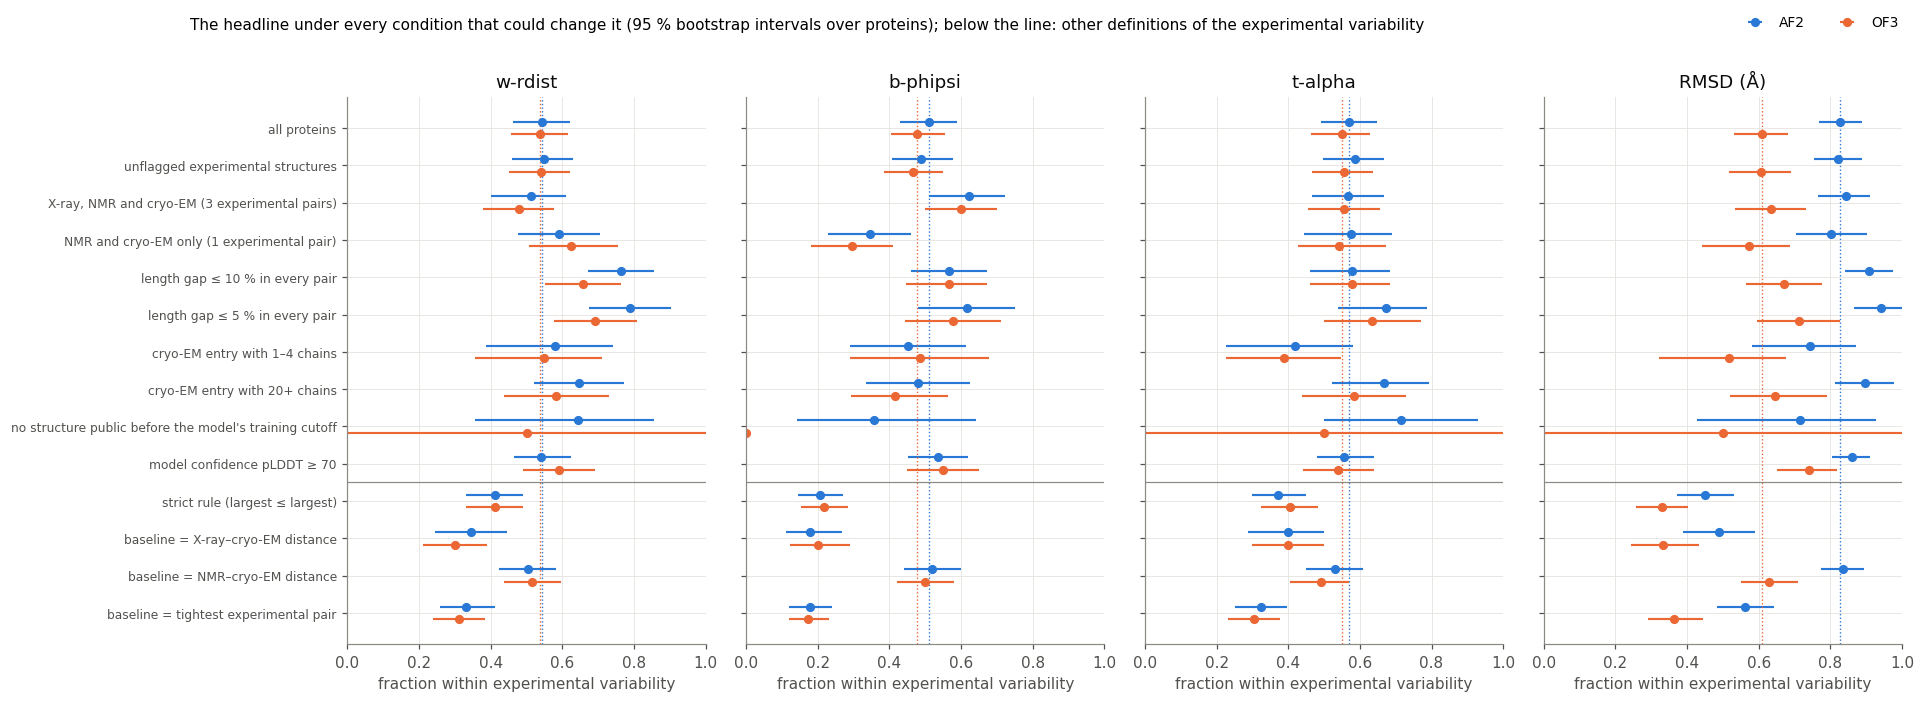

In [5]:
robust = robustness_table(records, structures, n_boot=2000)
robust.to_csv("results/robustness.csv", index=False)
display(robustness_wide(robust))

conditions = ROBUSTNESS_CONDITIONS + list(BASELINE_CONDITIONS.values())
y = np.arange(len(conditions))[::-1].astype(float)
fig, axes = plt.subplots(
    1, len(METRICS), figsize=(4.4 * len(METRICS), 6.4), sharey=True
)
for ax, m in zip(axes, METRICS):
    for pred, offset in (("AF2", 0.17), ("OF3", -0.17)):
        sub = (
            robust[(robust["metric"] == m) & (robust["prediction"] == pred)]
            .set_index("condition")
            .reindex(conditions)
        )
        frac = sub["fraction"].to_numpy(dtype=float)
        err = np.vstack(
            [
                np.clip(frac - sub["lo"].to_numpy(dtype=float), 0, None),
                np.clip(sub["hi"].to_numpy(dtype=float) - frac, 0, None),
            ]
        )
        ax.errorbar(
            frac,
            y + offset,
            xerr=np.nan_to_num(err),
            fmt="o",
            markersize=5,
            color=COLOR[pred],
            elinewidth=1.4,
            capsize=0,
            label=pred,
        )
        ax.axvline(
            sub.loc["all proteins", "fraction"], color=COLOR[pred], lw=0.9, ls=":"
        )
    ax.axhline(y[len(ROBUSTNESS_CONDITIONS) - 1] - 0.5, color=COLOR["rule"], lw=0.8)
    ax.set_xlim(0, 1)
    ax.set_title(LABEL[m])
    ax.set_xlabel("fraction within experimental variability")
axes[0].set_yticks(y, conditions, fontsize=8)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="upper right", ncol=2, fontsize=9, bbox_to_anchor=(0.99, 1.0)
)
fig.suptitle(
    "The headline under every condition that could change it (95 % bootstrap intervals over proteins); "
    "below the line: other definitions of the experimental variability",
    fontsize=10,
    x=0.42,
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
save(fig, "robustness")

get = robust.set_index(["condition", "metric", "prediction"])
for key, cond in (
    ("coverage_5", "length gap ≤ 5 % in every pair"),
    ("xray_cryoem", "baseline = X-ray–cryo-EM distance"),
    ("tightest", "baseline = tightest experimental pair"),
    ("unseen", "no structure public before the model's training cutoff"),
):
    for m in ("rmsd", "w_rdist_norm"):
        for pred in ("AF2", "OF3"):
            r = get.loc[(cond, m, pred)]
            findings[f"robust_{key}_{m}_{pred}"] = [float(r["fraction"]), int(r["n"])]

---
## 5. Which experimental method is the prediction closest to — and the role of context

Each protein gives one value per pair of methods (the median over its pairs of that type). The figure
shows them all, one point per protein: each experimental structure in turn is the reference, next to
its distance to the other experimental structures (grey) and to the two predictions. Read it within one
group — from the X-ray structure, is AF2 as close as the cryo-EM structure is? The table gives the
median over proteins. For the proteins with all three experimental methods: which one each prediction
is closest to. Then the distances split by the size of the cryo-EM entry: if NMR–cryo-EM grows with
the assembly while X-ray–cryo-EM does not, part of the gap between methods is the gap between a free
protein and a subunit of a complex.

In [ ]:
# Every pair type, one point per protein: each experimental structure as the reference,
# its distance to the other experimental structures (grey) and to the two predictions.
from matplotlib.lines import Line2D

per_pair = per_protein_pair_medians(records, METRICS)
GROUPS = [
    ("X-ray as reference", [("NMR", "X-ray–NMR"), ("cryo-EM", "X-ray–Cryo-EM"), ("AF2", "X-ray–AF2"), ("OF3", "X-ray–OF3")]),
    ("NMR as reference", [("X-ray", "X-ray–NMR"), ("cryo-EM", "NMR–Cryo-EM"), ("AF2", "NMR–AF2"), ("OF3", "NMR–OF3")]),
    ("cryo-EM as reference", [("X-ray", "X-ray–Cryo-EM"), ("NMR", "NMR–Cryo-EM"), ("AF2", "Cryo-EM–AF2"), ("OF3", "Cryo-EM–OF3")]),
    ("AF2 vs OF3", [("AF2–OF3", "AF2–OF3")]),
]
PARTNER_COLOR = {"AF2": COLOR["AF2"], "OF3": COLOR["OF3"]}

boxes, x, group_spans = [], 1.0, []
for g, (title, partners) in enumerate(GROUPS):
    start = x
    for partner, pair in partners:
        color = COLOR["AF2 vs OF3"] if title == "AF2 vs OF3" else PARTNER_COLOR.get(partner, COLOR["between methods"])
        boxes.append((x, partner, pair, color))
        x += 1.0
    group_spans.append((title, start, x - 1.0))
    x += 0.7  # air between groups

fig, axes = plt.subplots(2, 2, figsize=(14.5, 8.8))
rng = np.random.default_rng(0)
for ax, m in zip(axes.flat, METRICS):
    data = [per_pair.loc[per_pair["pair"] == pair, m].dropna().to_numpy(float) for _, _, pair, _ in boxes]
    floor_value = log_floor(*data)
    data = [positive(d, floor_value) for d in data]
    positions = [b[0] for b in boxes]
    bp = ax.boxplot(
        data,
        positions=positions,
        widths=0.6,
        whis=(5, 95),
        showfliers=False,
        patch_artist=True,
        medianprops={"color": COLOR["text"], "linewidth": 2},
        boxprops={"edgecolor": COLOR["rule"], "linewidth": 1},
        whiskerprops={"color": COLOR["rule"], "linewidth": 1},
        capprops={"color": COLOR["rule"], "linewidth": 1},
    )
    for patch, (_, _, _, color) in zip(bp["boxes"], boxes):
        patch.set_facecolor(color)
        patch.set_alpha(0.12)
    for (pos, _, _, color), d in zip(boxes, data):
        ax.scatter(pos + rng.uniform(-0.18, 0.18, len(d)), d, s=9, color=color, alpha=0.55, linewidths=0, zorder=3)
    ax.set_yscale("log")
    ax.set_xticks(positions, [f"{p}\nn={len(d)}" for (_, p, _, _), d in zip(boxes, data)], fontsize=8)
    for title, a, b in group_spans:
        ax.text((a + b) / 2, 1.01, title, transform=ax.get_xaxis_transform(), ha="center", va="bottom", fontsize=9, color=COLOR["text"])
    for _, _, b in group_spans[:-1]:
        ax.axvline(b + 0.85, color="#e6e5e1", lw=1, zorder=0)
    ax.set_xlim(positions[0] - 0.6, positions[-1] + 0.6)
    ax.set_title(LABEL[m], loc="left", fontsize=11, pad=22)
    ax.grid(axis="x", visible=False)
axes[0, 0].set_ylabel("distance (log scale)")
axes[1, 0].set_ylabel("distance (log scale)")
handles = [
    Line2D([], [], marker="o", ls="", ms=7, color=c, label=lbl)
    for lbl, c in (("another experimental structure", COLOR["between methods"]), ("AlphaFold2", COLOR["AF2"]),
                   ("OpenFold3", COLOR["OF3"]), ("AF2 vs OF3", COLOR["AF2 vs OF3"]))
]
fig.legend(handles=handles, loc="upper right", ncol=4, fontsize=9, bbox_to_anchor=(0.995, 1.0))
fig.suptitle("Every pair of structures, one point per protein (box: quartiles; line: median; whiskers: 5–95 %)", fontsize=11, x=0.01, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.96), h_pad=2.5)
save(fig, "method_pairs")

,rmsd,w_rdist_norm,b_phipsi,t_alpha,n_proteins
pair,,,,,
X-ray–NMR,2.930,0.226,0.026,0.117,90
X-ray–Cryo-EM,1.139,0.163,0.007,0.081,90
NMR–Cryo-EM,4.498,0.329,0.025,0.095,151
X-ray–AF2,1.008,0.393,0.007,0.111,90
NMR–AF2,4.534,0.479,0.048,0.129,151
Cryo-EM–AF2,1.504,0.334,0.017,0.105,151
X-ray–OF3,1.825,0.415,0.009,0.102,90
NMR–OF3,4.885,0.407,0.051,0.130,151
Cryo-EM–OF3,2.807,0.352,0.018,0.099,151


,closest to AF2 by rmsd (n=90),closest to AF2 by w_rdist_norm (n=90),closest to OF3 by rmsd (n=90),closest to OF3 by w_rdist_norm (n=90)
X-ray,47,27,43,27
NMR,7,37,10,38
Cryo-EM,36,26,37,25


,assembly,pair,n_proteins,rmsd,w_rdist_norm,b_phipsi,t_alpha
0,1–4 chains,X-ray–Cryo-EM,21,1.057,0.126,0.009,0.091
1,1–4 chains,NMR–Cryo-EM,31,3.468,0.237,0.017,0.062
2,1–4 chains,Cryo-EM–AF2,31,1.314,0.488,0.010,0.104
3,1–4 chains,NMR–AF2,31,4.267,0.391,0.047,0.139
4,1–4 chains,X-ray–AF2,21,0.799,0.698,0.006,0.097
5,5–19 chains,X-ray–Cryo-EM,47,1.292,0.164,0.007,0.101
6,5–19 chains,NMR–Cryo-EM,72,3.993,0.281,0.025,0.097
7,5–19 chains,Cryo-EM–AF2,72,1.740,0.384,0.017,0.105
8,5–19 chains,NMR–AF2,72,3.983,0.486,0.050,0.152
9,5–19 chains,X-ray–AF2,47,1.287,0.448,0.009,0.128


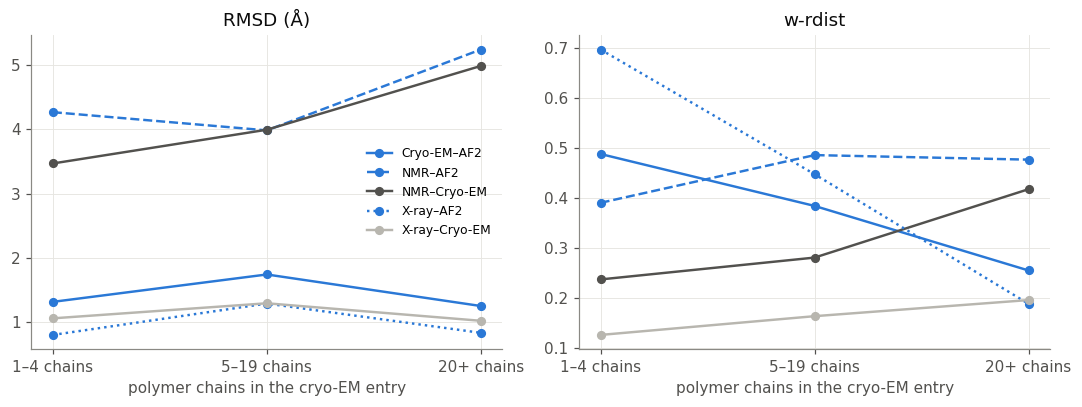

In [6]:
pair_table = method_pair_table(records)
pair_table.to_csv("results/method_pair_table.csv")
display(pair_table.round(3))
closest = pd.concat(
    [
        closest_experimental_method(records, pred, metric)
        for pred in ("AF2", "OF3")
        for metric in ("rmsd", "w_rdist_norm")
    ],
    axis=1,
)
display(closest)

ctx = context_table(records)
ctx.to_csv("results/context_table.csv", index=False)
display(ctx.round(3))
order = ["1–4 chains", "5–19 chains", "20+ chains"]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
styles = {
    "X-ray–Cryo-EM": (COLOR["same entry"], "-"),
    "NMR–Cryo-EM": (COLOR["between methods"], "-"),
    "Cryo-EM–AF2": (COLOR["AF2"], "-"),
    "NMR–AF2": (COLOR["AF2"], "--"),
    "X-ray–AF2": (COLOR["AF2"], ":"),
}
for ax, m in zip(axes, ["rmsd", "w_rdist_norm"]):
    for pair, g in ctx.groupby("pair"):
        g = g.set_index("assembly").reindex(order)
        color, ls = styles.get(pair, (COLOR["rule"], "-"))
        ax.plot(
            range(3), g[m], marker="o", markersize=5, color=color, ls=ls, label=pair
        )
    ax.set_xticks(range(3), order)
    ax.set_title(LABEL[m])
    ax.set_xlabel("polymer chains in the cryo-EM entry")
axes[0].legend(fontsize=8)
fig.tight_layout()
save(fig, "context_by_assembly")

---
## 6. Model confidence (pLDDT) and distance

pLDDT is each model's own confidence, averaged over its residues. If it is informative, low pLDDT
should go with larger distances to the experimental structures. ρ: Spearman correlation over proteins.

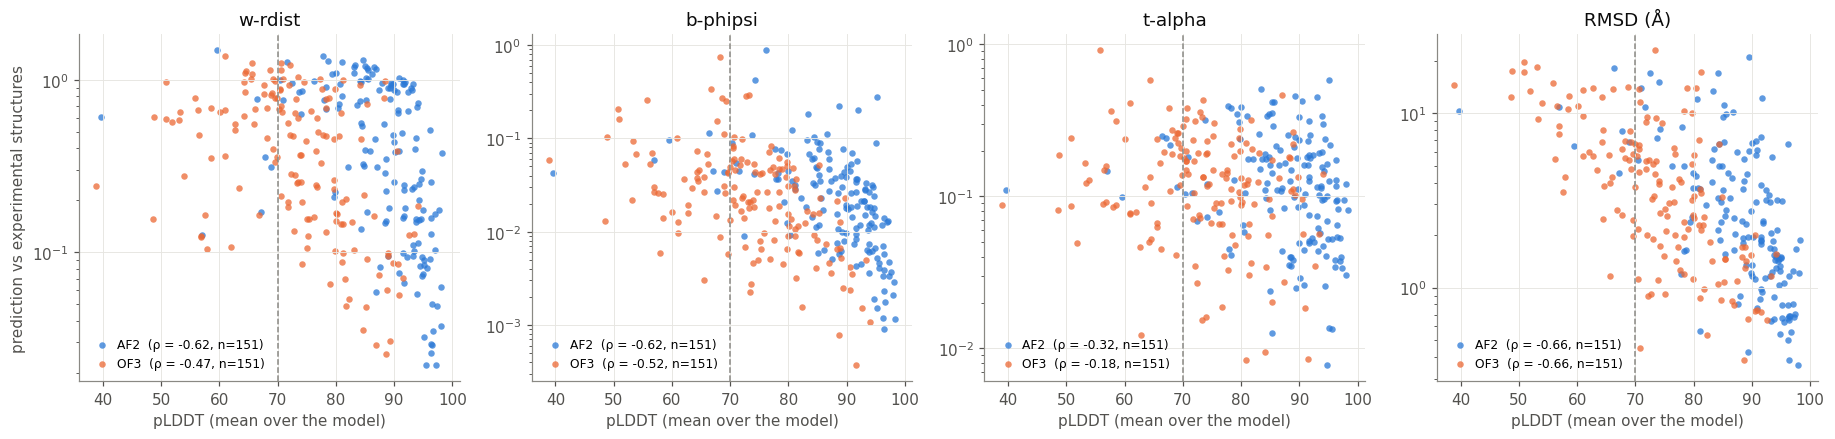

median pLDDT: AF2 89.8, OF3 73.5; OF3 ≥ 70 for 100 of 151 proteins


In [7]:
fig, axes = plt.subplots(
    1, len(METRICS), figsize=(4.2 * len(METRICS), 4.1), sharex=True
)
for ax, m in zip(axes, METRICS):
    for pred in ("AF2", "OF3"):
        sub = table[[f"plddt_{pred.lower()}", f"{m}__{pred.lower()}"]].dropna()
        rho = sub.corr(method="spearman").iloc[0, 1] if len(sub) > 2 else np.nan
        findings[f"rho_plddt_{m}_{pred}"] = float(rho)
        yv = sub[f"{m}__{pred.lower()}"].to_numpy(dtype=float)
        ax.scatter(
            sub[f"plddt_{pred.lower()}"],
            positive(yv, log_floor(yv)),
            s=18,
            color=COLOR[pred],
            alpha=0.75,
            linewidths=0,
            label=f"{pred}  (ρ = {rho:.2f}, n={len(sub)})",
        )
    ax.axvline(70, color=COLOR["rule"], linewidth=1, linestyle="--")
    ax.set_yscale("log")
    ax.set_title(LABEL[m])
    ax.set_xlabel("pLDDT (mean over the model)")
    ax.legend(loc="best", fontsize=8, handletextpad=0.2)
axes[0].set_ylabel("prediction vs experimental structures")
fig.tight_layout()
save(fig, "plddt_vs_distance")
plddt = table[["plddt_af2", "plddt_of3"]].apply(pd.to_numeric, errors="coerce")
findings["plddt_median"] = {
    "AF2": float(plddt["plddt_af2"].median()),
    "OF3": float(plddt["plddt_of3"].median()),
}
print(
    f"median pLDDT: AF2 {findings['plddt_median']['AF2']:.1f}, OF3 {findings['plddt_median']['OF3']:.1f}; "
    f"OF3 ≥ 70 for {int((plddt['plddt_of3'] >= 70).sum())} of {plddt['plddt_of3'].notna().sum()} proteins"
)

---
## 7. Training overlap: could the model have been trained on the experimental structure?

AF2 was trained on PDB entries released up to 30 April 2018 (Jumper et al. 2021); OpenFold3 on entries
deposited before 30 September 2021 (OpenFold3 model card). **Proteins:** how many have at least one
structure in this set that was public before each cutoff (notebook 01 states this as a property of the
set). **Pairs:** the w-rdist between a prediction and an experimental entry from before vs after the
cutoff, split by method, because newer entries are mostly cryo-EM (median over pairs; the pairs are
not independent, and the groups differ in more than their date).

In [8]:
overlap = training_overlap(structures)
n = len(overlap)
findings["seen"] = {
    "AF2": int(overlap["seen_af2"].sum()),
    "OF3": int(overlap["seen_of3"].sum()),
    "proteins": n,
}
print(
    f"proteins with a structure here public before the cutoff: AF2 {findings['seen']['AF2']} of {n}, "
    f"OF3 {findings['seen']['OF3']} of {n}"
)

rows = []
for r in records:
    if (
        r["category"] not in ("exp_vs_af2", "exp_vs_of3")
        or r.get("w_rdist_norm") is None
    ):
        continue
    method, _, pred = r["comparison"].partition("_vs_")
    if pred == "AF2":
        date, before = (
            r.get("release_date_a") or "",
            (r.get("release_date_a") or "9999") <= AF2_TRAINING_CUTOFF,
        )
    else:
        date, before = (
            r.get("deposition_date_a") or "",
            (r.get("deposition_date_a") or "9999") < OF3_TRAINING_CUTOFF,
        )
    if date:
        rows.append(
            {
                "prediction": pred,
                "method": method,
                "entry": "before cutoff" if before else "after cutoff",
                "w_rdist": r["w_rdist_norm"],
            }
        )
by_date = (
    pd.DataFrame(rows)
    .groupby(["prediction", "method", "entry"])["w_rdist"]
    .agg(n="size", median="median")
    .unstack("entry")
)
display(by_date.round(3))

proteins with a structure here public before the cutoff: AF2 137 of 151, OF3 149 of 151


n                     median              
entry              after cutoff before cutoff after cutoff before cutoff
prediction method                                                       
AF2        Cryo-EM          145             6        0.348         0.111
           NMR               19           132        0.683         0.416
           X-ray             28            62        0.749         0.267
OF3        Cryo-EM          113            38        0.422         0.241
           NMR                4           147        0.585         0.407
           X-ray             19            71        0.486         0.363

---
## 8. AlphaFold2 vs OpenFold3

Where the two predictions differ, and why the difference cannot be attributed to the architecture
alone: the AF2 models come from the AlphaFold Database, built with AlphaFold's full pipeline (deep
MSAs, and it can use PDB templates); the OF3 models here were predicted with ColabFold MSAs of a few
hundred sequences and no templates; the two training sets end at different dates. The comparison
is reported, but read as "these two sets of models", not "these two methods".

In [9]:
versus = summary[(summary["prediction"] == "AF2 vs OF3") & (summary["subset"] == "all")]
display(
    versus[
        [
            "metric",
            "n",
            "af2_closer",
            "af2_closer_lo",
            "af2_closer_hi",
            "median_diff",
            "median_diff_lo",
            "median_diff_hi",
        ]
    ].round(3)
)
msa = pd.to_numeric(table["msa_depth_of3"], errors="coerce")
print(
    f"OF3 MSA depth (sequences given to OpenFold3): median {msa.median():.0f}, range {msa.min():.0f}–{msa.max():.0f}"
)
for _, row in versus.iterrows():
    findings[f"af2_closer_{row['metric']}"] = float(row["af2_closer"])

,metric,n,af2_closer,af2_closer_lo,af2_closer_hi,median_diff,median_diff_lo,median_diff_hi
2,w_rdist_norm,151,0.424,0.344,0.503,-0.005,-0.019,0.000
5,b_phipsi,151,0.536,0.457,0.616,0.000,-0.001,0.001
8,t_alpha,151,0.530,0.450,0.609,0.001,-0.006,0.010
11,rmsd,151,0.755,0.682,0.821,0.242,0.136,0.349


OF3 MSA depth (sequences given to OpenFold3): median 202, range 6–301


---
## 9. The proteins farthest outside the experimental variability

Largest (prediction − experimental) in w-rdist and in RMSD, with the properties that may explain them:
confidence, OF3 MSA depth, length, context (cryo-EM chains), coverage (largest length gap among the
protein's pairs), training overlap and flags. The full table is `results/protein_table.csv`.

In [10]:
view = table.merge(
    strata[["protein_name", "max_length_gap", "seen_af2"]], on="protein_name"
).assign(
    af2_minus_exp=lambda d: d["w_rdist_norm__af2"] - d["w_rdist_norm__exp"],
    of3_minus_exp=lambda d: d["w_rdist_norm__of3"] - d["w_rdist_norm__exp"],
    af2_rmsd_minus_exp=lambda d: d["rmsd__af2"] - d["rmsd__exp"],
)
columns = [
    "protein_name",
    "af2_minus_exp",
    "of3_minus_exp",
    "af2_rmsd_minus_exp",
    "w_rdist_norm__exp",
    "plddt_af2",
    "plddt_of3",
    "msa_depth_of3",
    "length",
    "cryoem_chains",
    "max_length_gap",
    "seen_af2",
    "flagged",
]
print("Farthest by w-rdist (AF2):")
display(view.sort_values("af2_minus_exp", ascending=False)[columns].head(12).round(3))
print("Farthest by RMSD (AF2):")
display(
    view.sort_values("af2_rmsd_minus_exp", ascending=False)[columns].head(12).round(3)
)

Farthest by w-rdist (AF2):


,protein_name,af2_minus_exp,of3_minus_exp,af2_rmsd_minus_exp,w_rdist_norm__exp,plddt_af2,plddt_of3,msa_depth_of3,length,cryoem_chains,max_length_gap,seen_af2,flagged
69,Insulin-like growth factor 1,1.329,1.217,1.214,0.159,59.524,60.921,202,195,3,0.682,True,False
103,"Plastocyanin, chloroplastic",1.238,1.189,-0.388,0.033,81.083,72.127,202,168,17,0.411,True,False
21,Beta-diguetoxin-Dc1a,1.176,0.834,-0.458,0.104,78.705,71.982,7,94,2,0.404,True,False
73,Interleukin-6,1.092,0.930,-0.107,0.085,85.286,77.363,201,212,6,0.259,True,False
27,CD59 glycoprotein,0.989,0.996,0.070,0.096,79.304,64.368,202,128,7,0.398,True,False
15,Angiogenin,0.889,0.825,-0.743,0.056,89.841,77.627,213,147,82,0.184,True,False
12,Alpha-insect toxin LqhaIT,0.853,0.730,2.425,0.040,92.961,73.236,202,85,2,0.259,True,False
108,Protein FimF,0.848,0.423,-0.366,0.459,84.728,79.823,202,176,7,0.285,True,True
9,"Acyl carrier protein, mitochondrial",0.829,0.714,-0.210,0.540,77.737,65.574,202,156,56,0.494,True,False
70,Interleukin-13,0.825,0.516,-0.132,0.309,85.602,67.603,118,146,5,0.308,True,False


Farthest by RMSD (AF2):


,protein_name,af2_minus_exp,of3_minus_exp,af2_rmsd_minus_exp,w_rdist_norm__exp,plddt_af2,plddt_of3,msa_depth_of3,length,cryoem_chains,max_length_gap,seen_af2,flagged
111,RNA polymerase inhibitor p7,-0.021,-0.040,9.190,0.147,56.950,62.025,11,73,10,0.096,True,False
17,Apoptosis-associated speck-like protein contai...,0.515,0.107,7.922,0.447,72.445,62.720,207,195,14,0.103,True,True
100,Phage protein,0.437,0.223,7.286,0.172,39.651,69.160,30,130,3,0.000,False,False
67,Histone H2B type 1-J,0.076,-0.351,5.279,0.940,85.475,50.784,205,126,10,0.225,True,False
51,Eukaryotic translation initiation factor 1,-0.264,-0.421,4.214,0.988,80.524,51.900,203,113,52,0.167,True,True
66,Histone H2B,0.070,-0.251,3.768,0.897,84.394,53.298,208,123,14,0.203,False,False
53,Eukaryotic translation initiation factor eIF-1,-0.284,-0.329,3.017,1.002,83.560,70.269,202,108,48,0.167,True,False
12,Alpha-insect toxin LqhaIT,0.853,0.730,2.425,0.040,92.961,73.236,202,85,2,0.259,True,False
129,SsrA-binding protein,-0.249,-0.248,2.254,0.890,90.752,80.841,202,144,61,0.146,True,False
58,General transcription factor IIH subunit 5,-0.133,-0.087,1.774,0.445,68.944,69.934,202,71,8,0.108,True,False


---
## 10. What the measurement supports

Computed from the sections above.

*Indicative: this reading describes one run of the pipeline. It is not a final result and holds only as far as the outputs above show it.* In that run the sections support this reading:

* By RMSD, AlphaFold2 is within the experimental variability for most proteins; OpenFold3 less often.
  By the whole-chain Machaon metrics the two predictions are hard to tell apart.
* How large the fraction is depends above all on what "experimental variability" means: pooled over
  methods it is dominated by NMR, which differs from X-ray and cryo-EM in method, context (free
  protein vs subunit) and coverage. Against the X-ray–cryo-EM distance alone, or the tightest pair,
  the fraction is much lower.
* Restricting to coverage-matched proteins raises the fractions: part of the "experimental
  variability" is residues one structure lacks.
* Almost every protein had a structure public before the models' training cutoffs, so the set tests
  agreement on known proteins. The few unseen proteins cannot settle whether the models generalise.

In [11]:
def frac(key):
    value = findings.get(key)
    return (
        "n/a"
        if value is None
        else (
            f"{value[0]:.2f} (n={value[1]})"
            if isinstance(value, list) and len(value) == 2
            else f"{value[0]:.2f} [{value[1]:.2f}, {value[2]:.2f}]"
        )
    )


print("• Within experimental variability (all proteins):")
for m in METRICS:
    print(
        f"    {LABEL[m]:<10} AF2 {frac(f'within_{m}_AF2')}   OF3 {frac(f'within_{m}_OF3')}"
    )
print(
    "• RMSD, AF2: coverage-matched (≤ 5 %) "
    + frac("robust_coverage_5_rmsd_AF2")
    + " | baseline X-ray–cryo-EM "
    + frac("robust_xray_cryoem_rmsd_AF2")
    + " | tightest pair "
    + frac("robust_tightest_rmsd_AF2")
    + " | unseen by AF2 "
    + frac("robust_unseen_rmsd_AF2")
)
print(
    f"• AF2 closer to the experiments than OF3 (RMSD) for {findings['af2_closer_rmsd']:.0%} of proteins; "
    f"by w-rdist {findings['af2_closer_w_rdist_norm']:.0%}"
)
print(
    f"• Seen in training: AF2 {findings['seen']['AF2']} / {findings['seen']['proteins']}, OF3 {findings['seen']['OF3']} / {findings['seen']['proteins']}"
)
with open("results/measurement_summary.json", "w") as f:
    json.dump(findings, f, indent=2)
print("saved results/measurement_summary.json")

• Within experimental variability (all proteins):
    w-rdist    AF2 0.54 [0.46, 0.62]   OF3 0.54 [0.46, 0.62]
    b-phipsi   AF2 0.51 [0.43, 0.59]   OF3 0.48 [0.40, 0.56]
    t-alpha    AF2 0.57 [0.49, 0.65]   OF3 0.55 [0.47, 0.63]
    RMSD (Å)   AF2 0.83 [0.77, 0.89]   OF3 0.61 [0.53, 0.69]
• RMSD, AF2: coverage-matched (≤ 5 %) 0.94 (n=52) | baseline X-ray–cryo-EM 0.49 (n=90) | tightest pair 0.56 (n=151) | unseen by AF2 0.71 (n=14)
• AF2 closer to the experiments than OF3 (RMSD) for 75% of proteins; by w-rdist 42%
• Seen in training: AF2 137 / 151, OF3 149 / 151
saved results/measurement_summary.json
